# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from model import EvacuationModel
import json
from pathlib import Path


%matplotlib inline
plt.style.use('default')

# Run simulation and get agent and model data

In [2]:
# Run simulations for each exit scenario
def run_evacuation_simulation(n_agents=50, width=30, height=25, num_exits=3, dt=0.1, max_steps=2000):
    """Run a single evacuation simulation (no leaders) and return dataframes."""
    num_leaders = 0
    print(f"Creating model: exits={num_exits}, leaders={num_leaders}")

    model = EvacuationModel(
        n_agents=n_agents,
        width=width,
        height=height,
        num_exits=num_exits,
        num_leaders=num_leaders,
        dt=dt
    )

    for step in range(max_steps):
        model.step()
        if not model.running:
            print(f"Simulation completed at step {step}")
            break

    model_df = model.datacollector.get_model_vars_dataframe().reset_index(drop=True).copy()
    agent_df = model.datacollector.get_agent_vars_dataframe().reset_index(drop=True).copy()

    # Add metadata
    model_df["num_exits"] = num_exits
    agent_df["num_exits"] = num_exits

    return model_df, agent_df

# run for each exit count
exit_counts = [1, 2, 3]

all_model_dfs = []
all_agent_dfs = []

for exits in exit_counts:
    model_df, agent_df = run_evacuation_simulation(num_exits=exits)
    all_model_dfs.append(model_df)
    all_agent_dfs.append(agent_df)

# combine results
combined_model_df = pd.concat(all_model_dfs, ignore_index=True)
combined_agent_df = pd.concat(all_agent_dfs, ignore_index=True)

print("All simulations completed.")
print(f"Combined Model DataFrame shape: {combined_model_df.shape}")
print(f"Combined Agent DataFrame shape: {combined_agent_df.shape}")


Creating model: exits=1, leaders=0


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Simulation completed at step 1728
Creating model: exits=2, leaders=0


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Creating model: exits=3, leaders=0


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Simulation completed at step 1776
All simulations completed.
Combined Model DataFrame shape: (5506, 25)
Combined Agent DataFrame shape: (152263, 15)


# Optional
## Save to pickle

In [3]:
import os

# Create data directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Save to pickle
with open('data/model_data_exits.pkl', 'wb') as f:
    pickle.dump(model_df, f)

with open('data/agent_data_exits.pkl', 'wb') as f:
    pickle.dump(agent_df, f)

## Load pickle 

In [4]:
# with open('data/model_data.pkl', 'rb') as f:
#     model_df = pickle.load(f)

# with open('data/agent_data.pkl', 'rb') as f:
#     agent_df = pickle.load(f)

# print("Data loaded from pickle files")

# Analysis

## Stats over time

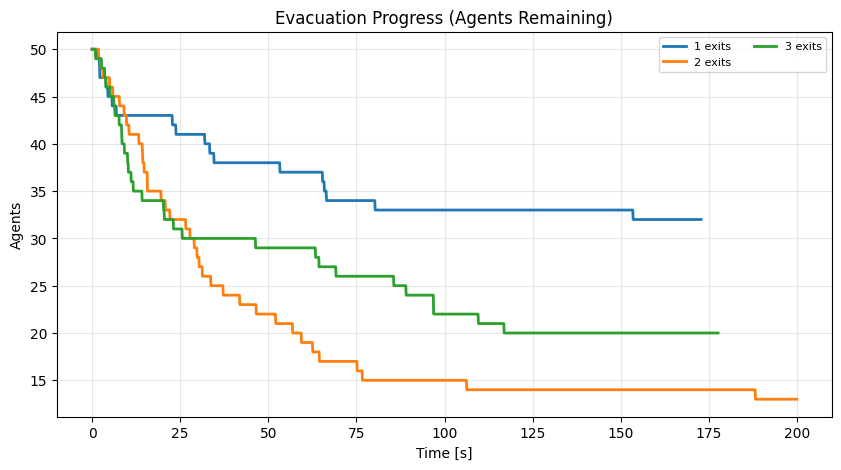

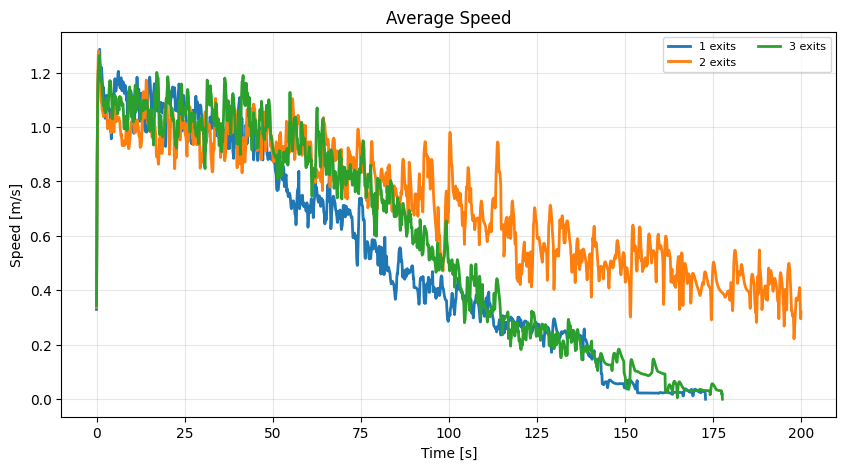

In [5]:
# exits
exit_counts = sorted(combined_model_df['num_exits'].unique())

def plot_by_exit(ycol, title, ylabel, kind='line', cumulative=False, smooth=False, per_exit=False, dt=0.1):
    """Plot model variable across exit configurations (no leaders)."""
    plt.figure(figsize=(10, 5))

    for exits in exit_counts:
        df = combined_model_df[combined_model_df['num_exits'] == exits]

        if ycol not in df.columns:
            continue

        t = np.arange(len(df)) * dt
        y = df[ycol]
        if cumulative:
            y = y.cumsum()
        if smooth:
            window = max(1, int(2.0 / dt))  # ~2s window
            y = y.rolling(window, min_periods=1).mean()

        label = f"{exits} exits"
        plt.plot(t, y, linewidth=2, label=label)

    plt.title(title)
    plt.xlabel('Time [s]')
    plt.ylabel(ylabel)
    plt.legend(fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.show()

# --- 1) Evacuation progress ---
plot_by_exit('Agents', 'Evacuation Progress (Agents Remaining)', 'Agents')

# --- 2) Average speed ---
plot_by_exit('Average_Speed', 'Average Speed', 'Speed [m/s]')

In [6]:
def run_evacuation_simulation(n_agents=50, width=30, height=25, num_exits=3, leader_percentage=0, dt=0.1, max_steps=2000):
    """Run a single evacuation simulation and return dataframes."""
    num_leaders = int(n_agents * leader_percentage / 100)
    print(f"\nCreating model: exits={num_exits}, leaders={num_leaders} ({leader_percentage}%)")
    
    model = EvacuationModel(n_agents=n_agents, width=width, height=height,
                            num_exits=num_exits, num_leaders=num_leaders, dt=dt)
    
    for step in range(max_steps):
        model.step()
        if not model.running:
            print(f"Simulation completed at step {step}")
            break
    
    model_df = model.datacollector.get_model_vars_dataframe().copy()
    agent_df = model.datacollector.get_agent_vars_dataframe().copy()

    # Add metadata for easy grouping later
    model_df["leader_percentage"] = leader_percentage
    agent_df["leader_percentage"] = leader_percentage
    
    return model_df, agent_df


# all leader options
leader_percentage = [0, 2, 6, 10, 20]

all_model_dfs = []
all_agent_dfs = []

for percentage in leader_percentage:
    model_df, agent_df = run_evacuation_simulation(leader_percentage=percentage)
    all_model_dfs.append(model_df)
    all_agent_dfs.append(agent_df)

# combine results
combined_model_df = pd.concat(all_model_dfs, ignore_index=True)
combined_agent_df = pd.concat(all_agent_dfs, ignore_index=True)

print("All simulations completed.")
print(f"Combined Model DataFrame shape: {combined_model_df.shape}")
print(f"Combined Agent DataFrame shape: {combined_agent_df.shape}")


Creating model: exits=3, leaders=0 (0%)


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Simulation completed at step 1378

Creating model: exits=3, leaders=1 (2%)


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Simulation completed at step 1709

Creating model: exits=3, leaders=3 (6%)


...

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)



Creating model: exits=3, leaders=10 (20%)


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Simulation completed at step 614
All simulations completed.
Combined Model DataFrame shape: (7557, 25)
Combined Agent DataFrame shape: (138322, 15)


C:\Users\User\AppData\Local\Temp\ipykernel_22224\3900198184.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_agent_df = pd.concat(all_agent_dfs, ignore_index=True)


In [7]:
import os

# Create data directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Save to pickle
with open('data/model_data_leaders.pkl', 'wb') as f:
    pickle.dump(model_df, f)

with open('data/agent_data_leaders.pkl', 'wb') as f:
    pickle.dump(agent_df, f)

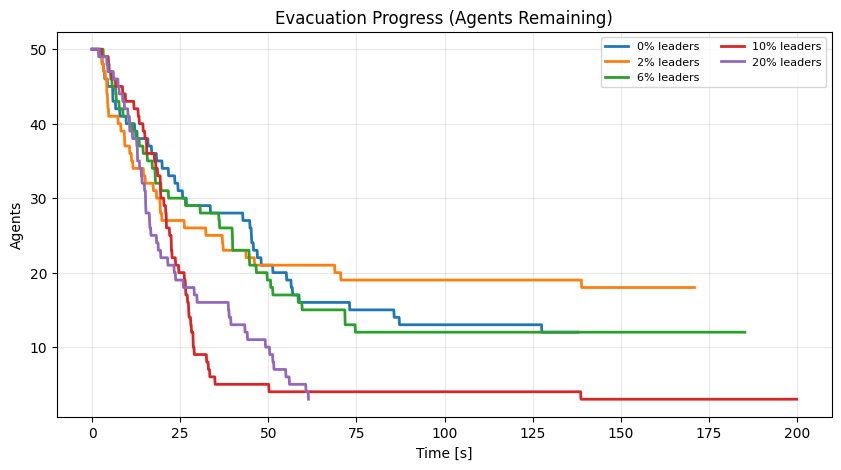

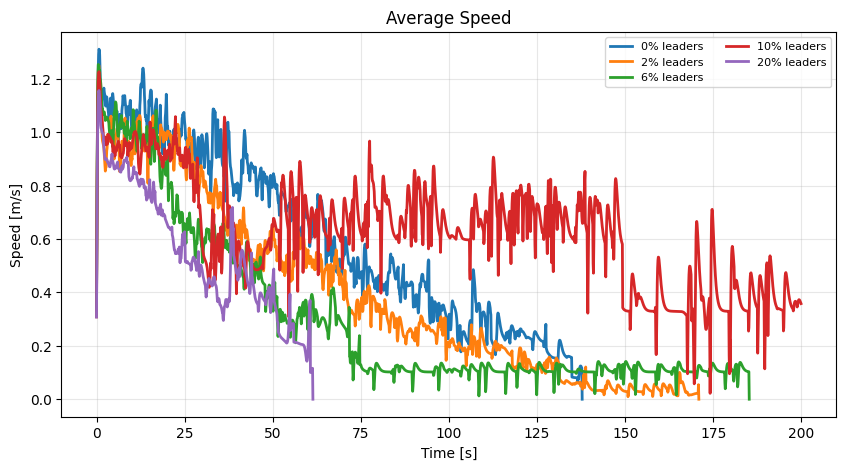

In [8]:
# leaders
leader_counts = sorted(combined_model_df['leader_percentage'].unique())

def plot_by_leader(ycol, title, ylabel, kind='line', cumulative=False, smooth=False, dt=0.1):
    """Plot model variable across leader percentages."""
    plt.figure(figsize=(10, 5))

    for percentage in leader_percentage:
        df = combined_model_df[combined_model_df['leader_percentage'] == percentage]

        if ycol not in df.columns:
            continue

        t = np.arange(len(df)) * dt
        y = df[ycol]
        if cumulative:
            y = y.cumsum()
        if smooth:
            window = max(1, int(2.0 / dt))  # ~2s window
            y = y.rolling(window, min_periods=1).mean()

        label = f"{percentage}% leaders"
        plt.plot(t, y, linewidth=2, label=label)

    plt.title(title)
    plt.xlabel('Time [s]')
    plt.ylabel(ylabel)
    plt.legend(fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.show()

# --- 1) Evacuation progress ---
plot_by_leader('Agents', 'Evacuation Progress (Agents Remaining)', 'Agents')

# --- 2) Average speed ---
plot_by_leader('Average_Speed', 'Average Speed', 'Speed [m/s]')

## Load experiment data functions

In [7]:
def load_experiment_results(exp_dir, load_detailed_data=False, parameter_filter=None):
    """
    Load results from a completed experiment with flexible data access.
    
    Args:
        exp_dir: Path to experiment directory
        load_detailed_data: If True, also load model/agent dataframes for each run
        parameter_filter: Dict to filter runs, e.g., {"v0": 2.0} or {"leader_proportion": 0.1}
    
    Returns:
        results_dict: Dictionary containing all experiment data
    """
    exp_dir = Path(exp_dir)
    
    # Load basic experiment info
    with open(exp_dir / "experiment_config.json", "r") as f:
        config = json.load(f)
    
    # Load summary and detailed results
    summary_df = pd.read_csv(exp_dir / "summary_results.csv")
    detailed_df = pd.read_csv(exp_dir / "detailed_results.csv")
    
    # Load raw results if available
    all_results = None
    if (exp_dir / "all_results.json").exists():
        with open(exp_dir / "all_results.json", "r") as f:
            all_results = json.load(f)
    
    print(f"Loaded experiment: {config['description']}")
    print(f"Date: {config['experiment_date']}")
    print(f"Total runs: {len(detailed_df)}")
    
    # Build results dictionary
    results = {
        "config": config,
        "summary_df": summary_df,
        "detailed_df": detailed_df,
        "all_results": all_results,
        "exp_dir": exp_dir
    }
    
    # Identify the varied parameter from the data
    varied_params = []
    for col in detailed_df.columns:
        if col not in ['run', 'total_time', 'evacuated', 'injured', 'evacuation_rate', 
                      'flow_rate', 'simulation_steps', 'computation_time', 
                      'final_agents_remaining', 'timeout']:
            if detailed_df[col].nunique() > 1:
                varied_params.append(col)
    
    if varied_params:
        print(f"Varied parameter(s): {', '.join(varied_params)}")
        results["varied_parameters"] = varied_params
    
    # Apply parameter filter if specified
    if parameter_filter:
        filtered_df = detailed_df.copy()
        for param, value in parameter_filter.items():
            if param in filtered_df.columns:
                filtered_df = filtered_df[filtered_df[param] == value]
                print(f"Filtered to {param} = {value}: {len(filtered_df)} runs")
            else:
                print(f"Warning: Parameter '{param}' not found in data")
        results["filtered_df"] = filtered_df
    
    # Load detailed simulation data if requested
    if load_detailed_data:
        print(f"Loading detailed simulation data...")
        detailed_data = load_simulation_data(exp_dir, parameter_filter)
        results["simulation_data"] = detailed_data
        print(f"Loaded simulation data for {len(detailed_data)} runs")
    
    return results

def load_simulation_data(exp_dir, parameter_filter=None):
    """
    Load model and agent dataframes for specific runs.
    
    Args:
        exp_dir: Path to experiment directory
        parameter_filter: Dict to filter which runs to load, e.g., {"v0": 2.0}
    
    Returns:
        simulation_data: Dict with run info and dataframes
    """
    exp_dir = Path(exp_dir)
    simulation_data = {}
    
    # Get all run directories
    run_dirs = [d for d in exp_dir.iterdir() if d.is_dir() and d.name.startswith(('v0_', 'leader_', 'param_', 'fire_'))]
    
    for run_dir in run_dirs:
        # Load run configuration
        run_config_file = run_dir / "run_config.json"
        if not run_config_file.exists():
            continue
            
        with open(run_config_file, "r") as f:
            run_config = json.load(f)
        
        # Apply filter if specified
        if parameter_filter:
            skip_run = False
            for param, value in parameter_filter.items():
                # Check in agent_params first, then model_params, then direct keys
                agent_value = run_config.get("agent_params", {}).get(param)
                model_value = run_config.get("model_params", {}).get(param)
                actual_value = run_config.get(param + "_actual")
                direct_value = run_config.get(param)
                
                run_value = agent_value or model_value or actual_value or direct_value
                
                if run_value != value:
                    skip_run = True
                    break
            
            if skip_run:
                continue
        
        # Load the dataframes
        model_data_file = run_dir / "model_data.pkl"
        agent_data_file = run_dir / "agent_data.pkl"
        
        run_data = {
            "run_config": run_config,
            "run_dir": run_dir,
            "run_name": run_dir.name
        }
        
        if model_data_file.exists():
            with open(model_data_file, "rb") as f:
                run_data["model_df"] = pickle.load(f)
        
        if agent_data_file.exists():
            with open(agent_data_file, "rb") as f:
                run_data["agent_df"] = pickle.load(f)
        
        simulation_data[run_dir.name] = run_data
    
    return simulation_data

def load_combined_model_df(exp_dir, parameter_name="leader_proportion", parameter_values=None, additional_filters=None):
    """
    Combine model_df from all runs for selected parameter values and filters into a single DataFrame.
    Adds columns for parameter value and run.
    """
    # first step is just checking if the parameter values provided are the same as the ones we recorded
    results = load_experiment_results(exp_dir)
    if parameter_name not in results['detailed_df'].columns:
        print(f"Parameter '{parameter_name}' not found in data")
        return None

    available_values = sorted(results['detailed_df'][parameter_name].unique())
    if parameter_values is None:
        parameter_values = available_values
    else:
        parameter_values = [v for v in parameter_values if v in available_values]

    dfs = []
    # load data for the specific parameter values
    for param_value in parameter_values:
        param_filter = {parameter_name: param_value}
        if additional_filters:
            param_filter.update(additional_filters)
        param_results = load_experiment_results(
            exp_dir, load_detailed_data=True, parameter_filter=param_filter
        )
        for run_name, run_data in param_results.get('simulation_data', {}).items():
            if 'model_df' not in run_data:
                continue
            df = run_data['model_df'].copy()
            df = df.reset_index(drop=True)
            df[parameter_name] = param_value
            df['run_name'] = run_name
            dfs.append(df)
    if not dfs:
        print("No model data found for the selected conditions.")
        return None
    combined_df = pd.concat(dfs, ignore_index=True)
    return combined_df

## Plot function

In [8]:
def plot_by_parameter(combined_df, parameter_name, ycol, title, ylabel, kind='line', cumulative=False, smooth=False, dt=0.1, max_steps=1000):
    plt.figure(figsize=(10, 5))
    param_values = sorted(combined_df[parameter_name].unique())
    for param_value in param_values:
        df = combined_df[combined_df[parameter_name] == param_value]
        # Align each run to max_steps, pad with last value
        runs = []
        for run_name, run_df in df.groupby('run_name'):
            run_df = run_df.copy()
            run_df['step'] = np.arange(len(run_df))
            run_df = run_df.set_index('step')
            run_df = run_df.reindex(range(max_steps), method='ffill')  # pad with last value
            runs.append(run_df[ycol].values)
        runs = np.array(runs)
        y = np.nanmean(runs, axis=0)
        t = np.arange(max_steps) * dt
        if cumulative:
            y = np.nancumsum(y)
        if smooth:
            window = max(1, int(2.0 / dt))
            y = pd.Series(y).rolling(window, min_periods=1).mean().values
        # Label formatting
        if parameter_name == "leader_proportion":
            label = f"{param_value:.0%} leaders"
        elif parameter_name == "fire_enabled":
            label = "Fire" if param_value else "No Fire"
        elif parameter_name == "exit_preset":
            label = str(param_value).replace("_", " ").title()
        else:
            label = f"{parameter_name}={param_value}"
        plt.plot(t, y, linewidth=2, label=label)
    plt.title(title)
    plt.xlabel('Time [s]')
    plt.ylabel(ylabel)
    plt.legend(fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### Varying proportion of leaders while fire is enables

Loaded experiment: Comprehensive extended agent experiment testing fire, multiple exits, and leadership effects on evacuation dynamics
Date: 2025-10-20T14:38:38.228766
Total runs: 300
Varied parameter(s): fire_enabled, exit_preset, num_exits, leader_proportion, num_leaders, seed, remaining_agents, overall_flow_rate, leaders_evacuated, leaders_remaining, leader_evacuation_rate, leader_flow_rate, injured_total, injured_rate, injured_fire, injured_smoke, injured_pressure, exit0_usage, exit1_usage, exit2_usage, exit_balance
Loaded experiment: Comprehensive extended agent experiment testing fire, multiple exits, and leadership effects on evacuation dynamics
Date: 2025-10-20T14:38:38.228766
Total runs: 300
Varied parameter(s): fire_enabled, exit_preset, num_exits, leader_proportion, num_leaders, seed, remaining_agents, overall_flow_rate, leaders_evacuated, leaders_remaining, leader_evacuation_rate, leader_flow_rate, injured_total, injured_rate, injured_fire, injured_smoke, injured_pressure, 

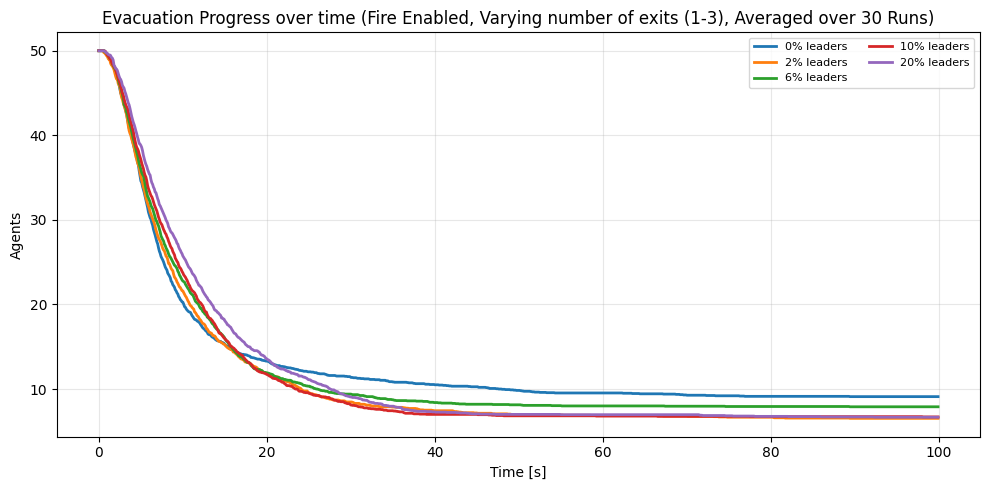

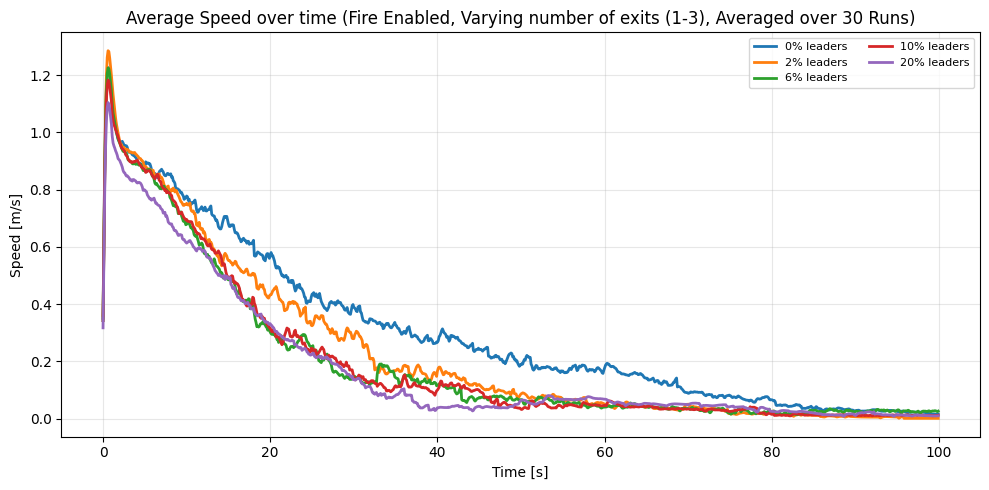

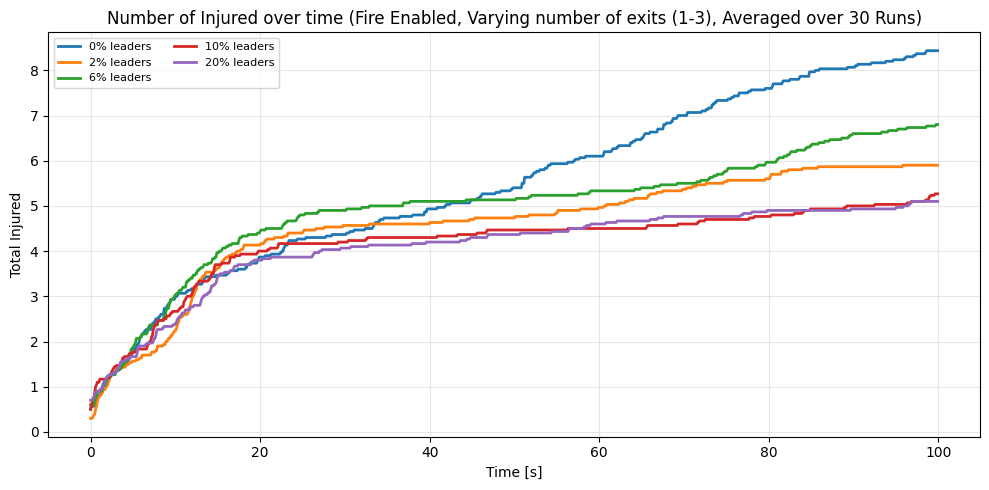

In [29]:
exp_dir = Path("experiments/extended_agents_full_20251020_143838")
combined_model_df = load_combined_model_df(
    exp_dir,
    parameter_name="leader_proportion",
    parameter_values=[0.0, 0.02, 0.06, 0.10, 0.20],
    additional_filters={"fire_enabled": True}
)
plot_by_parameter(
    combined_model_df,
    "leader_proportion",
    "Agents",
    "Evacuation Progress over time (Fire Enabled, Varying number of exits (1-3), Averaged over 30 Runs)",
    "Agents"
)
plot_by_parameter(
    combined_model_df,
    "leader_proportion",
    "Average_Speed",
    "Average Speed over time (Fire Enabled, Varying number of exits (1-3), Averaged over 30 Runs)",
    "Speed [m/s]"
)

plot_by_parameter(
    combined_model_df,
    "leader_proportion",
    "Injured_Total",
    "Number of Injured over time (Fire Enabled, Varying number of exits (1-3), Averaged over 30 Runs)",
    "Total Injured"
)

Loaded experiment: Comprehensive extended agent experiment testing fire, multiple exits, and leadership effects on evacuation dynamics
Date: 2025-10-20T14:38:38.228766
Total runs: 300
Varied parameter(s): fire_enabled, exit_preset, num_exits, leader_proportion, num_leaders, seed, remaining_agents, overall_flow_rate, leaders_evacuated, leaders_remaining, leader_evacuation_rate, leader_flow_rate, injured_total, injured_rate, injured_fire, injured_smoke, injured_pressure, exit0_usage, exit1_usage, exit2_usage, exit_balance
Loaded experiment: Comprehensive extended agent experiment testing fire, multiple exits, and leadership effects on evacuation dynamics
Date: 2025-10-20T14:38:38.228766
Total runs: 300
Varied parameter(s): fire_enabled, exit_preset, num_exits, leader_proportion, num_leaders, seed, remaining_agents, overall_flow_rate, leaders_evacuated, leaders_remaining, leader_evacuation_rate, leader_flow_rate, injured_total, injured_rate, injured_fire, injured_smoke, injured_pressure, 

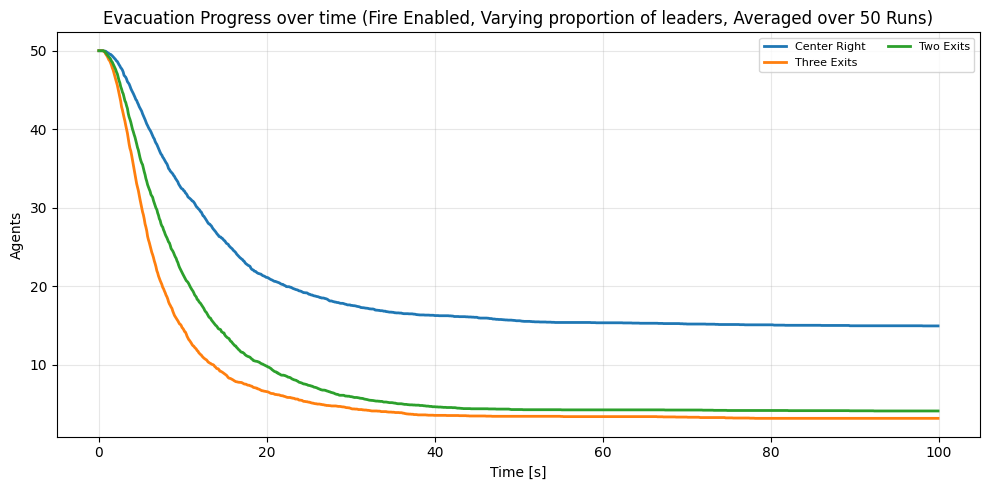

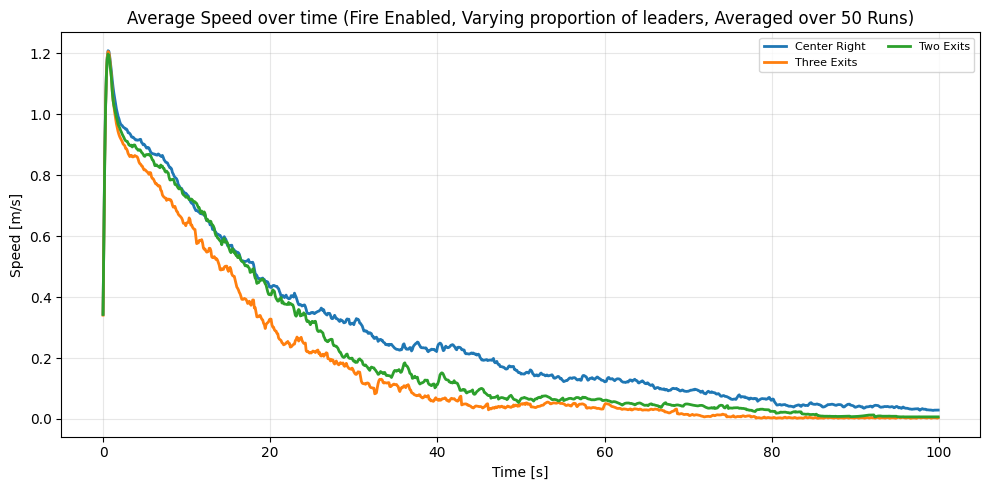

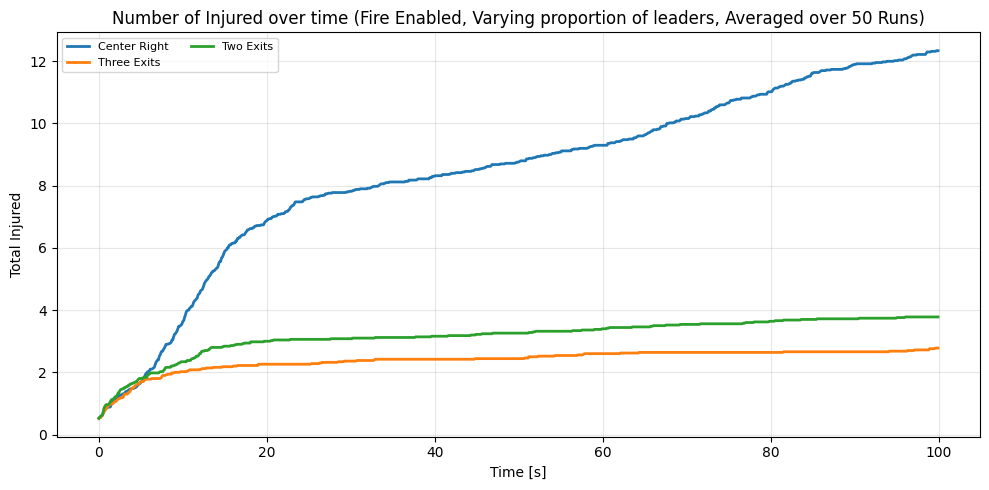

In [30]:
exp_dir = Path("experiments/extended_agents_full_20251020_143838")
combined_model_df = load_combined_model_df(
    exp_dir,
    parameter_name="exit_preset",
    parameter_values=["center_right", "two_exits", "three_exits"],
    additional_filters={"fire_enabled": True}
)
plot_by_parameter(
    combined_model_df,
    "exit_preset",
    "Agents",
    "Evacuation Progress over time (Fire Enabled, Varying proportion of leaders, Averaged over 50 Runs)",
    "Agents"
)
plot_by_parameter(
    combined_model_df,
    "exit_preset",
    "Average_Speed",
    "Average Speed over time (Fire Enabled, Varying proportion of leaders, Averaged over 50 Runs)",
    "Speed [m/s]"
)

plot_by_parameter(
    combined_model_df,
    "exit_preset",
    "Injured_Total",
    "Number of Injured over time (Fire Enabled, Varying proportion of leaders, Averaged over 50 Runs)",
    "Total Injured"
)

- If you want to explore more plots here are the possible model level columns that we record:

In [19]:
display(combined_model_df.columns)

Index(['Agents', 'Average_Speed', 'Exit_Flow_Total', 'Exit0_Flow',
       'Exit1_Flow', 'Exit2_Flow', 'Exit_Balance_Entropy', 'Exit0_Pressure',
       'Exit1_Pressure', 'Exit2_Pressure', 'Followers_Latched',
       'Leaders_Remaining', 'Mean_VisTerm', 'Mean_SmokeExposure',
       'Injured_Total', 'Injured_Fire', 'Injured_Smoke', 'Injured_Press',
       'Std_v0_init', 'Std_vmax', 'Std_radius', 'Std_mass', 'Std_vis',
       'Std_panic0', 'exit_preset', 'run_name'],
      dtype='object')